In [2]:
!pip install geopandas folium contextily shapely matplotlib


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------ --------------- 1.0/1.7 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.2 MB/s  0:00:00
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
    --------------------------------------- 0.5/22.9 MB 2.1 MB/s eta 0:00:11
   - -------------------------------------- 1.0/22.9 MB 2.5 MB/s eta 0:00:09
   --- ------------------------------------ 1.8/22.9 MB 2.9 MB/s eta 0:00:08
   ---- ----------------------------------- 2.6/22.9 MB 3.2 MB/s eta 0:00:07
   ------ --------------------------------- 3.7/22.9 MB 3.5 MB/s eta 0:00:06
   -------- ------------------------------- 5.0/22.9 MB 3.9 MB/s eta 0:00:05
   ---------- ----------------------------- 6.0/22.9 MB 4.1 MB/s eta 0:00:05
   ------------ --------------------------- 7.3/22.9 MB 4.4 MB/s eta 0:00:04
   --------------- ------------------------ 8.7/22.9 MB 4.6 MB/s eta 0:00:04
   ----------------

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from shapely.geometry import box
import warnings
warnings.filterwarnings('ignore')


In [24]:
# ── 1. Daten laden ────────────────────────────────────────────────────────────
df = pd.read_csv(r'C:\Users\Lukas\masterthesis\thesis_2026\data\final_flickr_dataset_with_metadata.csv')
df = df.dropna(subset=['latitude', 'longitude'])
output_path = r'C:\Users\Lukas\masterthesis\thesis_2026\data\kilimanjaro_photo_map.png'

In [9]:
# ── 2. GeoDataFrame ───────────────────────────────────────────────────────────
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)
gdf_utm = gdf.to_crs('EPSG:32737')

In [11]:
# ── 3. 1km x 1km Raster ───────────────────────────────────────────────────────
cell_size = 1000
xmin, ymin, xmax, ymax = gdf_utm.total_bounds
xmin = np.floor(xmin / cell_size) * cell_size
ymin = np.floor(ymin / cell_size) * cell_size
xmax = np.ceil(xmax / cell_size) * cell_size
ymax = np.ceil(ymax / cell_size) * cell_size

cells = []
for x in np.arange(xmin, xmax, cell_size):
    for y in np.arange(ymin, ymax, cell_size):
        cells.append(box(x, y, x + cell_size, y + cell_size))

grid = gpd.GeoDataFrame({'geometry': cells}, crs='EPSG:32737')
grid = grid.reset_index().rename(columns={'index': 'grid_id'})

In [12]:
# ── 4. Fotos pro Zelle zählen ─────────────────────────────────────────────────
joined = gpd.sjoin(gdf_utm, grid, how='left', predicate='within')
photo_counts = joined.groupby('index_right').size().reset_index(name='photo_count')
grid = grid.merge(photo_counts, left_on='grid_id', right_on='index_right', how='left')
grid['photo_count'] = grid['photo_count'].fillna(0)
grid_filled = grid[grid['photo_count'] > 0].copy()

In [13]:
# ── 5. Zurück in WGS84 ────────────────────────────────────────────────────────
grid_wgs = grid_filled.to_crs('EPSG:4326')

In [18]:
!pip install contextily

In [20]:
import contextily as ctx

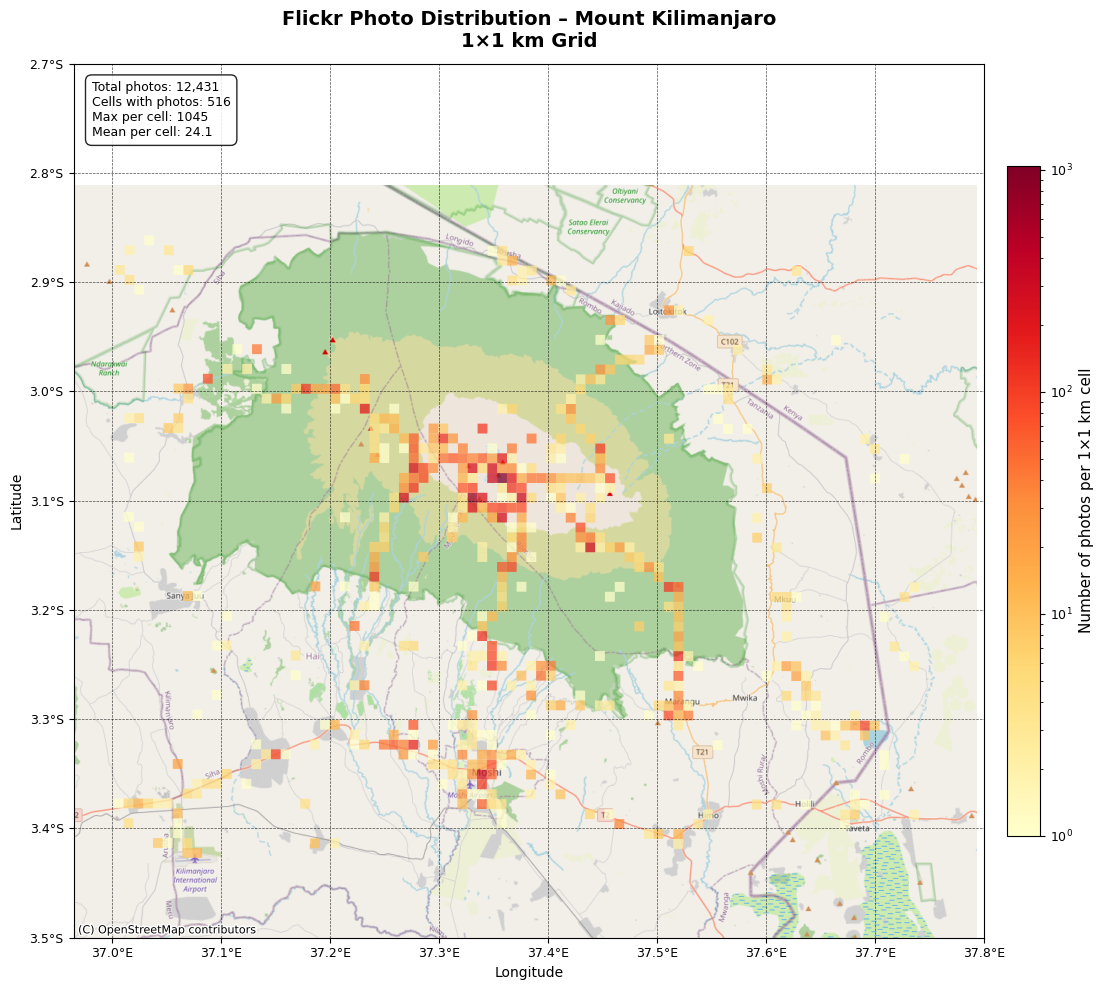

Gespeichert: C:\Users\Lukas\masterthesis\thesis_2026\data\kilimanjaro_photo_map.png


In [26]:
# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))

norm = mcolors.LogNorm(vmin=1, vmax=vmax)
cmap = plt.cm.YlOrRd

# In Web Mercator für contextily
grid_web = grid_wgs.to_crs('EPSG:3857')

grid_web.plot(
    column='photo_count',
    ax=ax,
    cmap=cmap,
    norm=norm,
    alpha=0.75,
    edgecolor='none'
)

# OSM Hintergrundkarte
ctx.add_basemap(
    ax,
    crs='EPSG:3857',
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=11
)

# ── Koordinatengitter in WGS84 ────────────────────────────────────────────────
from pyproj import Transformer
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)

# Achsengrenzen in WGS84 umrechnen
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

# Lat/Lon Ticks definieren
lon_ticks = np.arange(np.floor(df['longitude'].min()*10)/10,
                       np.ceil(df['longitude'].max()*10)/10 + 0.1, 0.1)
lat_ticks = np.arange(np.floor(df['latitude'].min()*10)/10,
                       np.ceil(df['latitude'].max()*10)/10 + 0.1, 0.1)

# Ticks in Web Mercator umrechnen
x_ticks = [transformer.transform(lon, df['latitude'].mean())[0] for lon in lon_ticks]
y_ticks = [transformer.transform(df['longitude'].mean(), lat)[1] for lat in lat_ticks]

ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{lon:.1f}°E' for lon in lon_ticks], fontsize=9)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{abs(lat):.1f}°S' for lat in lat_ticks], fontsize=9)

ax.grid(True, color='black', linewidth=0.5, alpha=0.7, linestyle='--')
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Number of photos per 1×1 km cell', fontsize=11)
cbar.ax.tick_params(labelsize=9)

# ── Statistik-Box ─────────────────────────────────────────────────────────────
stats_text = (
    f"Total photos: {len(df):,}\n"
    f"Cells with photos: {len(grid_filled):,}\n"
    f"Max per cell: {int(vmax)}\n"
    f"Mean per cell: {grid_wgs['photo_count'].mean():.1f}"
)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85))

ax.set_title('Flickr Photo Distribution – Mount Kilimanjaro\n1×1 km Grid',
             fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Gespeichert: {output_path}")